## Ejemplo Práctico

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Precisión: {accuracy:.4f}")
print("\nInforme de clasificación:")
print(report)

Precisión: 0.9561

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Live Coding

Vamos a entrenar un modelo de clasificación con Gradient Boosting utilizando el dataset de cáncer de mama. Se mostrará cómo ajustar hiperparámetros e interpretar el resultado.

1. Cargar dataset load_breast_cancer() desde Scikit-learn.



In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [4]:
# 1) Cargar dataset UCI (Original)
data = fetch_ucirepo(id=15)

| Variable                        | Qué representa                              | Intuición clínica                                               |
| ------------------------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **Clump_thickness**             | Espesor del conglomerado celular            | Tumores malignos tienden a formar masas más gruesas y compactas |
| **Uniformity_of_cell_size**     | Uniformidad en el tamaño de las células     | En tumores malignos las células varían mucho en tamaño          |
| **Uniformity_of_cell_shape**    | Uniformidad en la forma de las células      | Las células cancerosas suelen tener formas irregulares          |
| **Marginal_adhesion**           | Adhesión entre células en los bordes        | En cáncer, las células pierden adhesión normal                  |
| **Single_epithelial_cell_size** | Tamaño de células epiteliales individuales  | Aumento anormal puede indicar malignidad                        |
| **Bare_nuclei**                 | Núcleos “desnudos” (sin citoplasma visible) | Indicador fuerte de células anormales                           |
| **Bland_chromatin**             | Apariencia de la cromatina nuclear          | Cromatina irregular o granular es típica en malignidad          |
| **Normal_nucleoli**             | Presencia y tamaño de nucleolos             | Nucleolos prominentes son comunes en células cancerosas         |
| **Mitoses**                     | Cantidad de divisiones celulares observadas | Alta tasa mitótica → crecimiento agresivo                       |

In [5]:
X = data.data.features.copy()
y = data.data.targets.copy()

In [6]:
y.value_counts()

Class
2        458
4        241
Name: count, dtype: int64

* 2 → (Benigno)
* 4 → (Maligno)

In [7]:
X.isnull().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

2. Separar en train/test (80/20).


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("\nTrain:", X_train.shape, " Test:", X_test.shape)


Train: (559, 9)  Test: (140, 9)


3. Crear y entrenar un modelo con GradientBoostingClassifier.


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [11]:
pipeline.fit(X_train, y_train.values.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

4. Evaluar con accuracy_score y classification_report.


In [12]:
from sklearn.metrics import f1_score

y_pred = pipeline.predict(X_test)

print("\n=== Baseline (sin tuning) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n",
      classification_report(y_test, y_pred, labels=[2,4], target_names=["Benigno", "Maligno"]))


=== Baseline (sin tuning) ===
Accuracy: 0.9571428571428572

Matriz de confusión:
 [[89  3]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.97      0.97        92
     Maligno       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



Accuracy nos dice el desempeño general.
El classification report nos muestra cómo le va al modelo en cada clase.
Aquí vemos que el modelo tiene buen equilibrio entre precisión y recall en ambas.

* F1 mide el equilibrio entre precisión y recall. (“¿Qué tan bien estoy detectando una clase, sin equivocarme demasiado?”)
* Precisión responde: De todo lo que el modelo dijo que era “positivo”,
¿cuánto realmente lo era?
* Recall responde: De todos los casos que realmente eran positivos,
¿cuántos logré detectar?


5. Ajustar hiperparámetros: n_estimators, learning_rate, max_depth.


In [13]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, confusion_matrix, classification_report, make_scorer

# Cantidad de pasos (n_estimators)
# Tamaño de cada paso (learning_rate)
# Complejidad de cada paso (max_depth)
param_grid = {
    "model__n_estimators": [100, 200, 300], # n_estimators = “cuántos pasos de mejora” (cuántas “correcciones” hace el modelo.)
    "model__learning_rate": [0.05, 0.1, 0.2], # qué tan grande es cada corrección.
    # Bajo (0.05): correcciones pequeñas y cuidadosas → suele generalizar mejor, pero necesita más árboles.
    # Medio (0.1): equilibrio típico.
    # Alto (0.2): aprende más rápido, pero puede pasarse de largo y sobreajustar.
    "model__max_depth": [2, 3, 4] # la complejidad de cada árbol (qué tan “profundas” son las reglas).
    # depth 2: reglas simples, muy generales
    # depth 3: un poco más flexible
    # depth 4: más complejidad → puede capturar patrones finos… pero también ruido
}

# Voy a evaluar el modelo en 5 particiones, manteniendo la proporción de benignos/malignos en cada una, y mezclando los datos para que la evaluación sea justa y repetible.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define a custom F1 scorer con pos_label=4
f1_scorer = make_scorer(f1_score, pos_label=4, average='binary') # pos_label=4 F1 que se obtenga va a ser el F1 centrado en detectar la clase 4

grid = GridSearchCV(
    estimator=pipeline, # Use the pipeline as the estimator
    param_grid=param_grid,
    scoring=f1_scorer,  # F1 enfocado en Maligno (label=4)
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train.values.ravel())

print("\n=== GridSearchCV ===")
print("Mejores params:", grid.best_params_)
print("Mejor F1 (CV):", grid.best_score_)

best_gb = grid.best_estimator_

# Evaluación final en test
y_pred_best = best_gb.predict(X_test)

print("\n=== Test con mejores hiperparámetros ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best, pos_label=4, average='binary')) # Fix pos_label
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_pred_best, target_names=['Benigno', 'Maligno'])) # Fix target_names


=== GridSearchCV ===
Mejores params: {'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 100}
Mejor F1 (CV): 0.9593963289598719

=== Test con mejores hiperparámetros ===
Accuracy: 0.95
F1: 0.9278350515463918

Matriz de confusión:
 [[88  4]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        92
     Maligno       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



Primera conclusión: En validación cruzada, la mejor combinación logró un F1 ≈ 0.96 para detectar malignos.

Antes del tuning, tu F1 para maligno era aproximadamente: ~0.94

Después del tuning: ~0.93

O sea… no mejoró.

En datasets pequeños como breast cancer, Gradient Boosting ya viene muy bien configurado por defecto. A veces el tuning cambia poco o incluso baja levemente en test.

El tuning encontró una combinación con excelente desempeño en validación cruzada (F1 ≈ 0.96), pero en test el rendimiento fue similar al modelo base. Esto muestra que el modelo ya estaba bien calibrado y que el tuning no siempre garantiza mejoras sustanciales.

6. Visualizar feature_importances_.


* Es el peso o relevancia que el modelo le da a cada variable para hacer sus predicciones


Top 10 variables por importancia:
                        feature  importance
1      Uniformity_of_cell_size    0.751866
5                  Bare_nuclei    0.122888
0              Clump_thickness    0.034764
2     Uniformity_of_cell_shape    0.031026
7              Normal_nucleoli    0.022616
6              Bland_chromatin    0.014994
3            Marginal_adhesion    0.014558
8                      Mitoses    0.004770
4  Single_epithelial_cell_size    0.002518


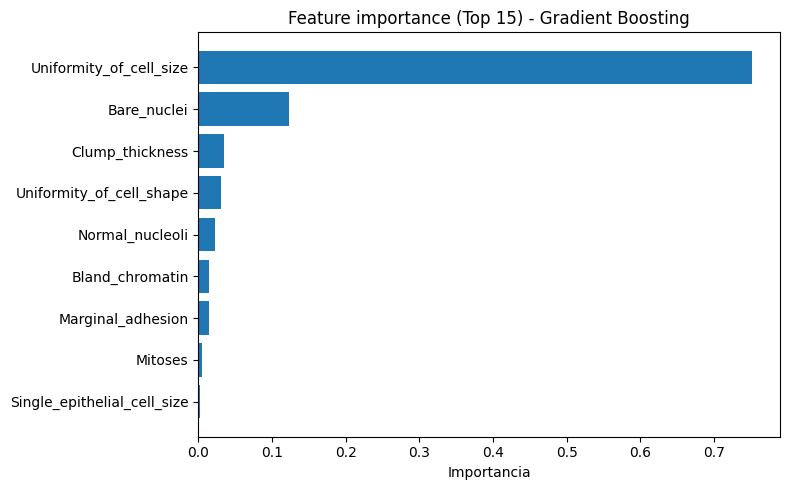

In [14]:
import matplotlib.pyplot as plt

importances = best_gb.named_steps['model'].feature_importances_ # Access feature_importances_ from the model within the pipeline
imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 variables por importancia:\n", imp_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(imp_df["feature"].head(15)[::-1], imp_df["importance"].head(15)[::-1])
plt.title("Feature importance (Top 15) - Gradient Boosting")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

| Variable                        | Qué representa                              | Intuición clínica                                               |
| ------------------------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **Clump_thickness**             | Espesor del conglomerado celular            | Tumores malignos tienden a formar masas más gruesas y compactas |
| **Uniformity_of_cell_size**     | Uniformidad en el tamaño de las células     | En tumores malignos las células varían mucho en tamaño          |
| **Uniformity_of_cell_shape**    | Uniformidad en la forma de las células      | Las células cancerosas suelen tener formas irregulares          |
| **Marginal_adhesion**           | Adhesión entre células en los bordes        | En cáncer, las células pierden adhesión normal                  |
| **Single_epithelial_cell_size** | Tamaño de células epiteliales individuales  | Aumento anormal puede indicar malignidad                        |
| **Bare_nuclei**                 | Núcleos “desnudos” (sin citoplasma visible) | Indicador fuerte de células anormales                           |
| **Bland_chromatin**             | Apariencia de la cromatina nuclear          | Cromatina irregular o granular es típica en malignidad          |
| **Normal_nucleoli**             | Presencia y tamaño de nucleolos             | Nucleolos prominentes son comunes en células cancerosas         |
| **Mitoses**                     | Cantidad de divisiones celulares observadas | Alta tasa mitótica → crecimiento agresivo                       |

* El 75% del “poder de decisión” del modelo está concentrado en UNA sola variable.
* Aunque entrenamos el modelo con muchas variables, el algoritmo descubrió que solo una o dos son realmente determinantes para clasificar maligno vs benigno.

7. Realizar validación cruzada con cross_val_score.


In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_gb, X, y.values.ravel(), cv=cv, scoring=f1_scorer)
print("\n=== Validación cruzada (F1) con modelo final ===")
print("F1 por fold:", np.round(scores, 4))
print("F1 promedio:", scores.mean().round(4))
print("Desv. estándar:", scores.std().round(4))


=== Validación cruzada (F1) con modelo final ===
F1 por fold: [0.9574 0.9278 0.9697 0.9474 0.9053]
F1 promedio: 0.9415
Desv. estándar: 0.0227


El modelo obtiene un F1 promedio de 0.94 para la clase maligna, lo que indica muy buen equilibrio entre precisión y recall en la detección de casos malignos.

Los valores por fold se mantienen relativamente consistentes (entre ~0.90 y ~0.97), lo que sugiere estabilidad en diferentes particiones de los datos.

La desviación estándar es baja (0.0227), lo que indica que el rendimiento no varía drásticamente según cómo se dividan los datos.

No se observa evidencia de sobreajuste severo, ya que el desempeño es consistente entre folds.

En conjunto, el modelo muestra buena capacidad de generalización y comportamiento robusto para clasificar casos malignos.

8. Discutir limitaciones y buenas prácticas.

**Buenas prácticas:**

- Usar CV para tuning y reservar test para evaluación final (no tocarlo durante el ajuste).
- Controlar overfitting bajando learning_rate y subiendo n_estimators con cuidado.
- Limitar max_depth para evitar modelos demasiado complejos.
- Revisar importancia de variables como guía, no como causalidad.

## LIVE CODING 2

Vamos a implementar modelos avanzados de boosting con XGBoost y CatBoost, comparando su rendimiento con GradientBoostingClassifier. También exploraremos interpretabilidad con SHAP.

1. Cargar el dataset Breast Cancer.



In [16]:
!pip -q install xgboost catboost shap

In [17]:
# !pip install ucimlrepo

In [18]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [19]:
# 1) Cargar dataset UCI (Original)
data = fetch_ucirepo(id=15)

| Variable                        | Qué representa                              | Intuición clínica                                               |
| ------------------------------- | ------------------------------------------- | --------------------------------------------------------------- |
| **Clump_thickness**             | Espesor del conglomerado celular            | Tumores malignos tienden a formar masas más gruesas y compactas |
| **Uniformity_of_cell_size**     | Uniformidad en el tamaño de las células     | En tumores malignos las células varían mucho en tamaño          |
| **Uniformity_of_cell_shape**    | Uniformidad en la forma de las células      | Las células cancerosas suelen tener formas irregulares          |
| **Marginal_adhesion**           | Adhesión entre células en los bordes        | En cáncer, las células pierden adhesión normal                  |
| **Single_epithelial_cell_size** | Tamaño de células epiteliales individuales  | Aumento anormal puede indicar malignidad                        |
| **Bare_nuclei**                 | Núcleos “desnudos” (sin citoplasma visible) | Indicador fuerte de células anormales                           |
| **Bland_chromatin**             | Apariencia de la cromatina nuclear          | Cromatina irregular o granular es típica en malignidad          |
| **Normal_nucleoli**             | Presencia y tamaño de nucleolos             | Nucleolos prominentes son comunes en células cancerosas         |
| **Mitoses**                     | Cantidad de divisiones celulares observadas | Alta tasa mitótica → crecimiento agresivo                       |

In [20]:
X = data.data.features.copy()
y = data.data.targets.copy()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

2. Entrenar un modelo con XGBClassifier.


In [22]:
# XGBoost (XGBClassifier) requiere etiquetas de clase consecutivas desde 0 (p. ej., 0/1).
# Convertimos el target original (2=benigno, 4=maligno) a binario (0=benigno, 1=maligno),
# dejando "maligno" como clase positiva para calcular F1 de forma consistente.
y_train_bin = (y_train.values.ravel() == 4).astype(int)
y_test_bin  = (y_test.values.ravel()  == 4).astype(int)

In [23]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Pipeline: aquí podrías agregar pasos antes del modelo si quisieras
xgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

# Entrenar
xgb_pipe.fit(X_train, y_train_bin)
y_pred = xgb_pipe.predict(X_test)

print("\n=== XGBClassifier ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1 (maligno=1):", f1_score(y_test_bin, y_pred, pos_label=1))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_bin, y_pred))
print("\nClassification report:\n", classification_report(y_test_bin, y_pred, target_names=["Benigno", "Maligno"]))


=== XGBClassifier ===
Accuracy: 0.95
F1 (maligno=1): 0.9278350515463918

Matriz de confusión:
 [[88  4]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        92
     Maligno       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



In [24]:
from sklearn.metrics import roc_auc_score

y_proba = xgb_pipe.predict_proba(X_test)[:, 1]  # prob de maligno=1
auc = roc_auc_score(y_test_bin, y_proba)
print("AUC:", round(auc, 4))

AUC: 0.9905


El modelo separa muy bien benignos de malignos.

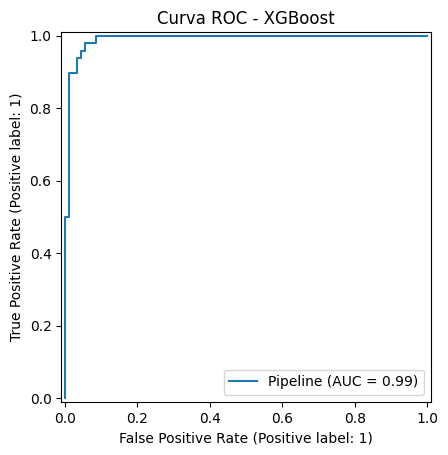

In [25]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(xgb_pipe, X_test, y_test_bin)
plt.title("Curva ROC - XGBoost")
plt.show()

Buena generalización (accuracy 0.95).

Detecta muy bien malignos (recall 0.94).

Balance sólido (F1 0.93).

Separación casi perfecta (AUC 0.99).

La curva está pegada al eje superior izquierdo.

El AUC de 0.99 indica excelente capacidad de separación.

Esto significa que, ajustando el umbral, podríamos priorizar recall clínico si fuera necesario.

3. Ajustar parámetros: max_depth, learning_rate, n_estimators.


Optimizar estos hiperparámetros de XGBoost:
* max_depth → complejidad del árbol
* learning_rate → tamaño del paso en cada iteración
* n_estimators → cantidad de árboles

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [100, 200, 300]
}

grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="roc_auc",      # más robusto que accuracy
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train_bin)

print("Mejores parámetros encontrados:")
print(grid.best_params_)

print("Mejor AUC CV:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros encontrados:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Mejor AUC CV: 0.99175106835525


* Un modelo más simple generaliza mejor en este dataset.

4. Evaluar métricas: accuracy, F1, AUC.


In [27]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n=== XGBoost Optimizado ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1:", f1_score(y_test_bin, y_pred))
print("AUC:", roc_auc_score(y_test_bin, y_prob))


=== XGBoost Optimizado ===
Accuracy: 0.9571428571428572
F1: 0.9375
AUC: 0.9912817028985508


* El tuning confirmó que no necesitamos árboles profundos.
Con max_depth = 2 el modelo logra una excelente capacidad de separación sin sobreajustar.

5. Repetir con CatBoostClassifier.


In [28]:
!pip -q install catboost

In [29]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

In [30]:
y_train_bin = (y_train.values.ravel() == 4).astype(int)
y_test_bin  = (y_test.values.ravel()  == 4).astype(int)

In [31]:
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # opcional
    ("model", CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=42
    ))
])

In [32]:
cat_pipe.fit(X_train, y_train_bin)

y_pred = cat_pipe.predict(X_test)
y_proba = cat_pipe.predict_proba(X_test)[:, 1]

print("\n=== CatBoostClassifier ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1 (maligno=1):", f1_score(y_test_bin, y_pred))
print("AUC:", roc_auc_score(y_test_bin, y_proba))

print("\nMatriz de confusión:\n", confusion_matrix(y_test_bin, y_pred))
print("\nClassification report:\n", classification_report(y_test_bin, y_pred, target_names=["Benigno", "Maligno"]))


=== CatBoostClassifier ===
Accuracy: 0.95
F1 (maligno=1): 0.9278350515463918
AUC: 0.9911684782608695

Matriz de confusión:
 [[88  4]
 [ 3 45]]

Classification report:
               precision    recall  f1-score   support

     Benigno       0.97      0.96      0.96        92
     Maligno       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



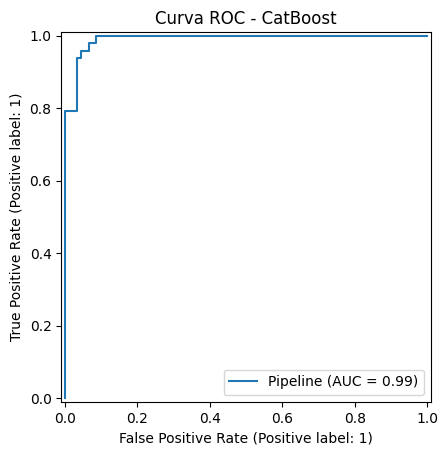

In [33]:
RocCurveDisplay.from_estimator(cat_pipe, X_test, y_test_bin)
plt.title("Curva ROC - CatBoost")
plt.show()

In [34]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__iterations": [200, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__depth": [2, 3, 4, 5]
}

grid = GridSearchCV(
    cat_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train_bin)

print("Mejores parámetros:", grid.best_params_)
print("Mejor AUC CV:", grid.best_score_)
best_cat = grid.best_estimator_

Mejores parámetros: {'model__depth': 2, 'model__iterations': 200, 'model__learning_rate': 0.05}
Mejor AUC CV: 0.9933643809635159


In [35]:
y_pred = best_cat.predict(X_test)
y_proba = best_cat.predict_proba(X_test)[:, 1]

print("\n=== CatBoost Optimizado ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("F1:", f1_score(y_test_bin, y_pred))
print("AUC:", roc_auc_score(y_test_bin, y_proba))


=== CatBoost Optimizado ===
Accuracy: 0.95
F1: 0.9263157894736842
AUC: 0.9941123188405797


CatBoost te dio prácticamente lo mismo que XGBoost en este dataset.


Cuando el dataset es numérico y relativamente limpio, varios algoritmos de boosting convergen a rendimientos muy parecidos.

CatBoost y XGBoost logran un AUC cercano a 0.99, lo que indica una separación excelente entre benignos y malignos.

En este dataset numérico, la diferencia práctica entre ambos modelos es mínima.

6. Visualizar importancia de variables.


Top 10 variables:
                        feature  importance
5                  Bare_nuclei   27.020992
1      Uniformity_of_cell_size   14.257847
0              Clump_thickness   13.383324
7              Normal_nucleoli   10.912576
2     Uniformity_of_cell_shape   10.637297
6              Bland_chromatin    7.948399
3            Marginal_adhesion    7.017552
4  Single_epithelial_cell_size    4.609036
8                      Mitoses    4.212977


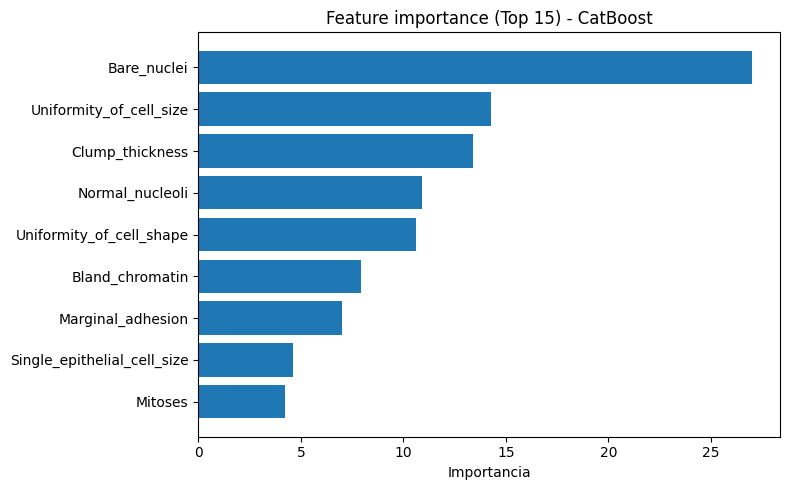

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) sacar el modelo desde el pipeline
cat_model = cat_pipe.named_steps["model"]  # si estás usando best_cat, cambia cat_pipe por best_cat

# 2) obtener importancias
importances = cat_model.get_feature_importance()  # default: PredictionValuesChange

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 variables:\n", imp_df.head(10))

# 3) gráfico
plt.figure(figsize=(8,5))
top = imp_df.head(15)[::-1]
plt.barh(top["feature"], top["importance"])
plt.title("Feature importance (Top 15) - CatBoost")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

El modelo está priorizando variables relacionadas con estructura y uniformidad celular, que clínicamente tienen sentido en la diferenciación benigno/maligno.

7. Aplicar SHAP para explicación local y global.


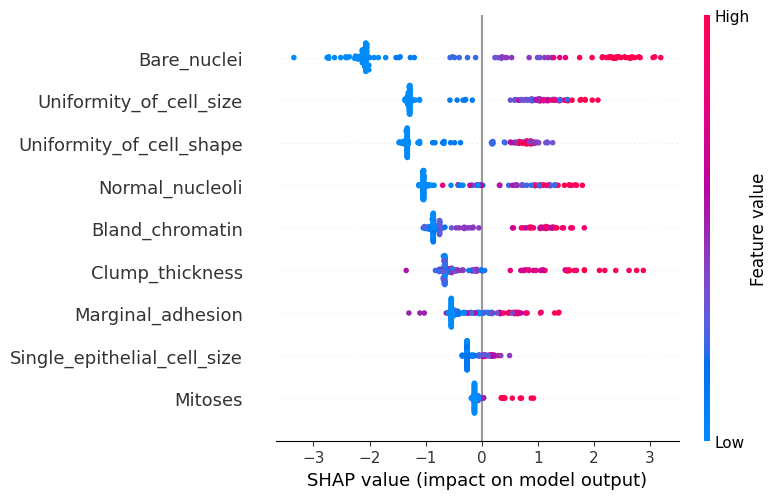

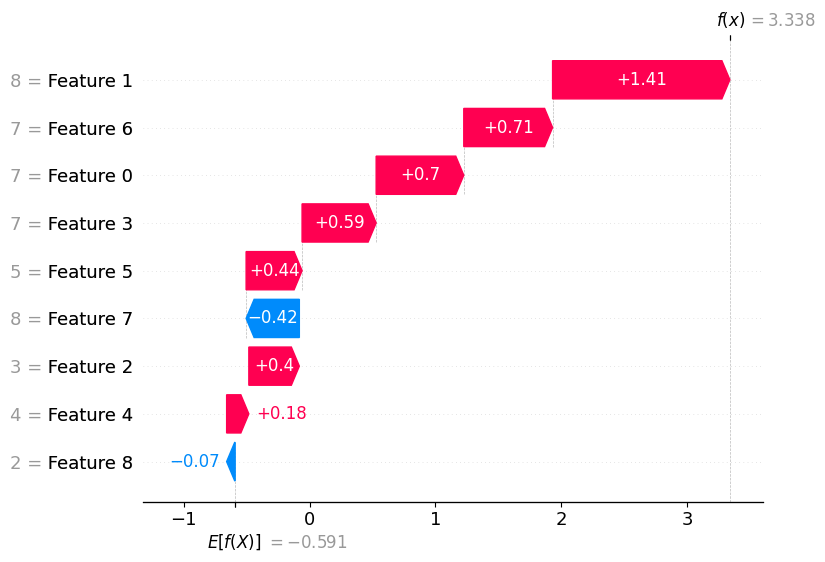

Predicción del modelo (0=benigno, 1=maligno): 1
Probabilidad de maligno: 0.9657025337219238


In [37]:
# Si no lo tienes instalado:
# !pip -q install shap

import shap
import numpy as np
import matplotlib.pyplot as plt

# 1) Sacar partes del pipeline ya entrenado
imputer = xgb_pipe.named_steps["imputer"]
model   = xgb_pipe.named_steps["model"]

# 2) Transformar datos (importante: SHAP ve lo que ve el modelo)
X_train_imp = imputer.transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Mantener nombres de variables
feature_names = X_train.columns

# 3) Explainer para modelos de árboles
explainer = shap.TreeExplainer(model)

# Para clasificación binaria, shap_values puede devolver:
# - una matriz (n_samples, n_features)  o
# - una lista [clase0, clase1]
shap_values = explainer.shap_values(X_test_imp)

# Normalizamos para quedarnos con la clase positiva (maligno=1)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]   # clase 1 = maligno
else:
    shap_values_pos = shap_values

# ====== GLOBAL: resumen (beeswarm) ======
shap.summary_plot(
    shap_values_pos,
    X_test_imp,
    feature_names=feature_names,
    show=True
)

# ====== LOCAL: explicar un caso específico ======
i = 0  # cambia el índice para mirar otra fila
x_i = X_test_imp[i]

# waterfall moderno (SHAP >= 0.40 suele usar Explanation)
try:
    exp = explainer(X_test_imp)  # devuelve shap.Explanation
    shap.plots.waterfall(exp[i], max_display=10)
except Exception:
    # fallback compatible con versiones antiguas
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_pos[i],
            base_values=base_value,
            data=x_i,
            feature_names=feature_names
        ),
        max_display=10
    )

print("Predicción del modelo (0=benigno, 1=maligno):", int(model.predict([x_i])[0]))
print("Probabilidad de maligno:", float(model.predict_proba([x_i])[0,1]))

Bare_nuclei es la variable dominante.

Valores altos (rojo) empujan fuertemente hacia maligno (SHAP positivo).

Valores bajos (azul) empujan hacia benigno (SHAP negativo).

El modelo parte de un riesgo promedio.

Luego cada característica del paciente mueve la predicción hacia benigno o maligno.

En este caso, múltiples características celulares elevadas empujan fuertemente hacia malignidad.

8. Comparar rendimiento y tiempos.

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# CV (la misma para todos)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scorer F1 para clase positiva = maligno (1)
f1_scorer = make_scorer(f1_score, pos_label=1, average="binary")

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "f1": f1_scorer
}

def eval_model(name, model, X, y_bin, cv):
    out = cross_validate(
        model,
        X,
        y_bin,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    return {
        "modelo": name,
        "ACC_mean": np.mean(out["test_accuracy"]),
        "ACC_std": np.std(out["test_accuracy"]),
        "F1_mean": np.mean(out["test_f1"]),
        "F1_std": np.std(out["test_f1"]),
        "AUC_mean": np.mean(out["test_roc_auc"]),
        "AUC_std": np.std(out["test_roc_auc"]),
        "fit_time_mean(s)": np.mean(out["fit_time"]),
        "fit_time_std(s)": np.std(out["fit_time"]),
        "score_time_mean(s)": np.mean(out["score_time"]),
        "score_time_std(s)": np.std(out["score_time"])
    }

# y_bin debe ser 0/1 (0=benigno, 1=maligno)
# Define y_bin for the full dataset X
y_bin = (y.values.ravel() == 4).astype(int) # Convert original labels 2, 4 to 0, 1

results = []
results.append(eval_model("GradientBoosting", best_gb, X, y_bin, cv))
results.append(eval_model("XGBoost (pipe)", xgb_pipe, X, y_bin, cv))
results.append(eval_model("CatBoost", cat_model, X, y_bin, cv))

df_compare = pd.DataFrame(results).sort_values("AUC_mean", ascending=False)
df_compare

,modelo,ACC_mean,ACC_std,F1_mean,F1_std,AUC_mean,AUC_std,fit_time_mean(s),fit_time_std(s),score_time_mean(s),score_time_std(s)
2,CatBoost,0.967102,0.005684,0.952095,0.008888,0.993206,0.003421,0.308879,0.006989,0.005640,0.000487
1,XGBoost (pipe),0.961377,0.007265,0.943749,0.011344,0.991528,0.005720,0.034256,0.001088,0.009139,0.000675
0,GradientBoosting,0.959908,0.015533,0.941522,0.022732,0.990461,0.003499,0.197925,0.014809,0.007073,0.000895


**Conclusiones (rendimiento + tiempos)**

* Mejor rendimiento global: CatBoost
  - Tiene los mejores promedios en las 3 métricas: Accuracy = 0.967, F1 = 0.952, AUC = 0.993.
  - Además es estable (desviaciones bajas: ACC_std ~0.0057, F1_std ~0.0089, AUC_std ~0.0034).

* Segundo lugar: XGBoost (pipe)
  - Muy buen desempeño, pero un poco por debajo de CatBoost: ACC = 0.961, F1 = 0.944, AUC = 0.992.
  - También es estable (std relativamente baja).

* GradientBoosting queda tercero
  - Métricas levemente más bajas: ACC = 0.960, F1 = 0.942, AUC = 0.991.
  - Y es el más variable en F1 (F1_std ~0.0227), o sea, su desempeño cambia más entre folds.

**Conclusiones de tiempos**

* Más rápido entrenando: XGBoost
  - fit_time_mean ~ 0.062 s, muy por debajo de CatBoost (~ 0.439 s) y GradientBoosting (~0.370 s).
  - Si tu foco es iterar rápido (muchas pruebas), XGB te da velocidad.

* Más rápido prediciendo: CatBoost
  - score_time_mean ~0.013 s, el menor de los tres.
  - En escenarios de “muchas predicciones” (producción), esto suma.

Si quiero máxima calidad predictiva (y consistencia): CatBoost.

Si quiero buen rendimiento pero entrenar ultra rápido para probar cosas: XGBoost.

Si quiero un baseline clásico y simple (pero menos estable en F1): GradientBoosting.